# Transformée de Fourier

In [1]:
# import
import matplotlib.pyplot as plt; from scipy.io import wavfile
%run ./init.py

## 1. Propriétés intéressantes

### Aliasing / repliement spectral

En présentant le spectre, la FFT permet de directement voir le repliement spectral / aliasing résultant de l'échantillonnage d'un signal à une fréquence trop basse.
Si $f = fs/2 + 4000$, son pic d'énergie sera **replié** à $fs/2 - 4000$.

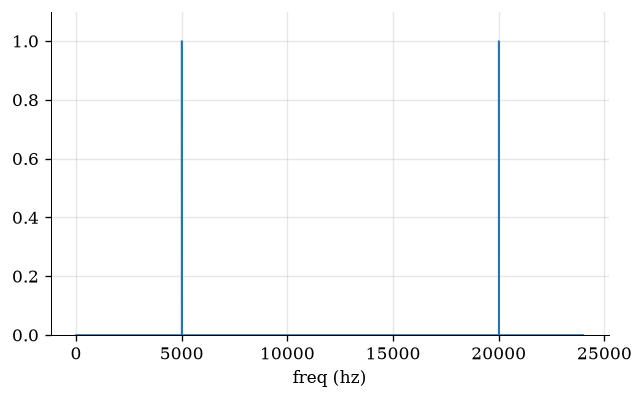

In [2]:
# init locals
f1 = 5000
f2 = fs/2 + 4000

# create signal
x1, t = get_sine(f1, sampling_rate = fs, duration_in_sec = 1)
x2, t = get_sine(f2, sampling_rate = fs, duration_in_sec = 1)
x = x1 + x2 

# fft
n = len(x)
X = np.fft.rfft(x, n)
freqs = np.fft.rfftfreq(n, 1/fs)

# plot fft
plt.plot(freqs, np.abs(X) / len(X), '-');
plt.ylim([0, 1.1]); plt.xlabel('freq (hz)'); plt.show();

### Résolution fréquentielle

Augmenter le nombre de fréquences utilisées permet d'obtenir une courbe fréquentielle plus lissée. (peut être réalisé en augmentant `num_freqs` ou en utilisant du zero padding)

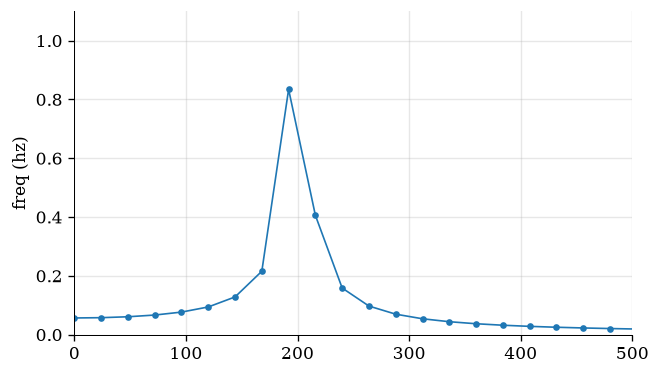

In [3]:
# init locals
num_freqs = 2000

# create signal
x, t = get_sine(200, sampling_rate = fs, duration_in_sec = 1)

# fft
X = np.fft.rfft(x, num_freqs)
freqs = np.fft.rfftfreq(num_freqs, 1/fs)

# plot fft
plt.plot(freqs, np.abs(X) / len(X), '.-');
plt.ylim([0, 1.1]); plt.xlim([0, 500]); plt.ylabel('freq (hz)'); plt.show();

### Pouvoir de séparation fréquentiel

Mais c'est la durée de l'enregistrement original $x(t)$ qui détermine le pouvoir de séparation entre deux fréquences.

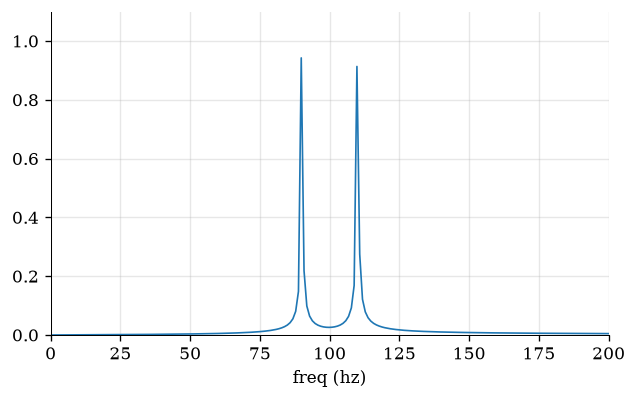

In [4]:
# init locals
duration_in_sec = 1
n_padding = 100

# create signal
x1, t = get_sine(90, sampling_rate = fs, duration_in_sec=duration_in_sec)
x2, t = get_sine(110, sampling_rate = fs, duration_in_sec=duration_in_sec, phase = math.pi/2)
x = x1 + x2

# zero pad end
x = np.pad(x, (0, n_padding))

# fft
n = len(x)
X = np.fft.rfft(x, n)
freqs = np.fft.rfftfreq(n, 1/fs)

# plot fft
plt.plot(freqs, np.abs(X) / len(X));
plt.xlim([0, 200]); plt.ylim([0, 1.1]); plt.xlabel('freq (hz)'); plt.show()

en effet plus les fréquences sont proches, plus on a besoin de temps (de signal) pour que le battement entre les deux réalise une période entière et fasse s'annuler l'air sous la courbe du produit avec le cos / sin (c.f. notebook fft_deconstruct)

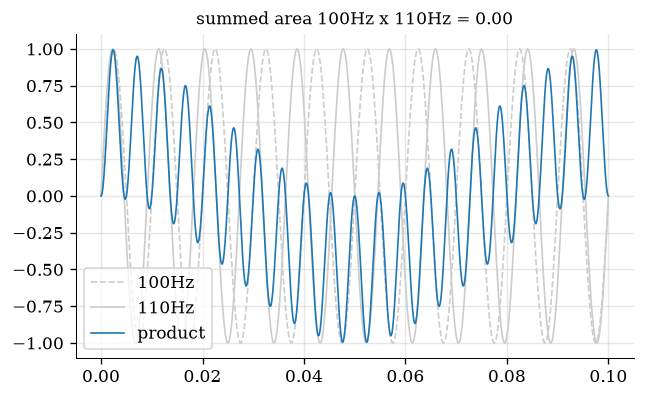

In [5]:
# define signals
f1 = 100; f2 = 110
duration_in_sec = 0.1

# create signals
x1, t = get_sine(f1, sampling_rate = fs, duration_in_sec = duration_in_sec)
x2, t = get_sine(f2, sampling_rate = fs, duration_in_sec = duration_in_sec)

# area under multiplied curves
y = np.multiply(x1, x2)

# plot
plt.plot(t, x1, '--', color = [0.8, 0.8, 0.8], label = f'{f1}Hz')
plt.plot(t, x2, color = [0.8, 0.8, 0.8], label = f'{f2}Hz')
plt.plot(t, y, '-', label = f'product')
plt.title(f'summed area {f1}Hz x {f2}Hz = {(np.sum(y) / len(y)):0.2f}')
plt.legend();

- tf d'un Dirac (c.f. TdS1_Ch1_Cplts_Ch1_Ch2_table_TF.pdf)
- tf d'une porte (c.f. TdS1_Ch1_Cplts_Ch1_Ch2_table_TF.pdf)
- translation temporelle = déphasage fréquentiel (TdS1_Ch1_Cplts_Ch1_Ch2_table_TF.pdf)
- modulation temporelle = translation fréquentielle (TdS1_Ch1_Cplts_Ch1_Ch2_table_TF.pdf)
- dérivation temporelle = multiplication fréquentielle (récursif) (TdS1_Ch1_Cplts_Ch1_Ch2_table_TF.pdf)

